In [1]:
import numpy as np

In [2]:
matrix = np.ones((5,5))

matrix[1:4, 1:4] = 0

print(matrix)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [3]:
np.random.seed(42)
#Randomize numbers for the array
data = np.random.randn(100,3)

normalized = (data - data.mean(axis=0)) / data.std(axis=0)

print(normalized.mean(axis=0))
print(normalized.std(axis=0))

[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
[1. 1. 1.]


In [4]:
X = np.random.randn(50,3)

true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50)*0.1

In [5]:
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated:", theta_hat)
print("True:", true_theta)

Estimated: [ 2.51723721 -1.19783796  3.72399266]
True: [ 2.5 -1.2  3.7]


Exercise 5: Pandas Data Analysis

In [6]:
import pandas as pd
import numpy as np

In [7]:
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1,2,3,4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0,100),
    'assignments_completed': np.random.randint(0,11, n_students),
    'hours_studied': np.random.normal(15,5,n_students).clip(1,40)
}

df = pd.DataFrame(data)

In [8]:
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [9]:
df.isnull().sum()

,0
student_id,0
major,0
year,0
exam_score,10
assignments_completed,0
hours_studied,5


In [10]:
#Filling in missing values
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

In [11]:
df.groupby('major')['exam_score'].mean()

,exam_score
major,
Biology,75.503150
CS,76.425184
Math,74.683689
Physics,75.406509


In [12]:
df.groupby('major')['exam_score'].mean().idxmax()

'CS'

In [13]:
df['hours_studied'].corr(df['exam_score'])

np.float64(-0.05598138347292439)

In [14]:
df['performance'] = pd.cut(
    df['exam_score'],
    bins=[0,70,80,90,100],
    labels=['Needs Improvement','Average','Good','Excellent']
)

In [15]:
df.groupby(['major','year']).agg({
    'student_id':'count',
    'exam_score':'mean',
    'hours_studied':'mean'
})

student_id  exam_score  hours_studied
major   year                                       
Biology 1             13   76.570059      12.677806
        2             12   74.899613      13.426372
        3             14   80.178476      14.486815
        4             15   70.697689      14.253944
CS      1             12   77.098194      13.039480
        2              7   76.155936      13.995784
        3              9   72.347626      15.039892
        4             18   78.119997      16.275541
Math    1             11   74.053167      19.001215
        2              9   81.226714      12.345468
        3             10   72.017537      15.175871
        4             16   73.103066      17.419175
Physics 1             13   77.828686      13.489911
        2             12   73.277734      14.616778
        3             17   73.134319      14.199901
        4             12   78.130194      15.550491

In [16]:
#GEt largest exam score
df.nlargest(10, 'exam_score')

,student_id,major,year,exam_score,assignments_completed,hours_studied,performance
27,1027,Math,2,100.000000,4,2.716265,Excellent
57,1057,CS,2,100.000000,8,11.870035,Excellent
68,1068,Biology,3,98.146586,1,11.379991,Excellent
82,1082,CS,2,96.439441,0,7.378547,Excellent
132,1132,CS,4,96.330334,10,17.546891,Excellent
100,1100,Physics,1,96.221562,5,17.440220,Excellent
171,1171,CS,4,95.923873,0,24.434141,Excellent
15,1015,CS,1,93.967930,0,8.859730,Excellent
4,1004,Physics,4,93.657745,6,15.287370,Excellent
96,1096,Math,2,92.654542,2,6.148784,Excellent


In [17]:
#Plotting a picot table
pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

year,1,2,3,4
major,,,,
Biology,76.570059,74.899613,80.178476,70.697689
CS,77.098194,76.155936,72.347626,78.119997
Math,74.053167,81.226714,72.017537,73.103066
Physics,77.828686,73.277734,73.134319,78.130194


Exercise 6: Visualization

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

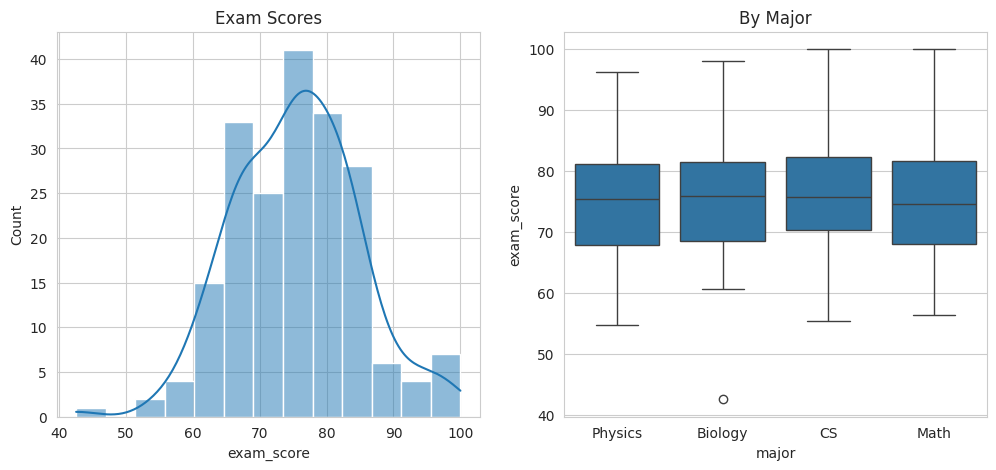

In [19]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

sns.histplot(df['exam_score'], kde=True, ax=ax[0])
ax[0].set_title("Exam Scores")

sns.boxplot(data=df, x='major', y='exam_score', ax=ax[1])
ax[1].set_title("By Major")

plt.show()

In [ ]:
sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)

plt.title("Hours vs Score")
plt.show()

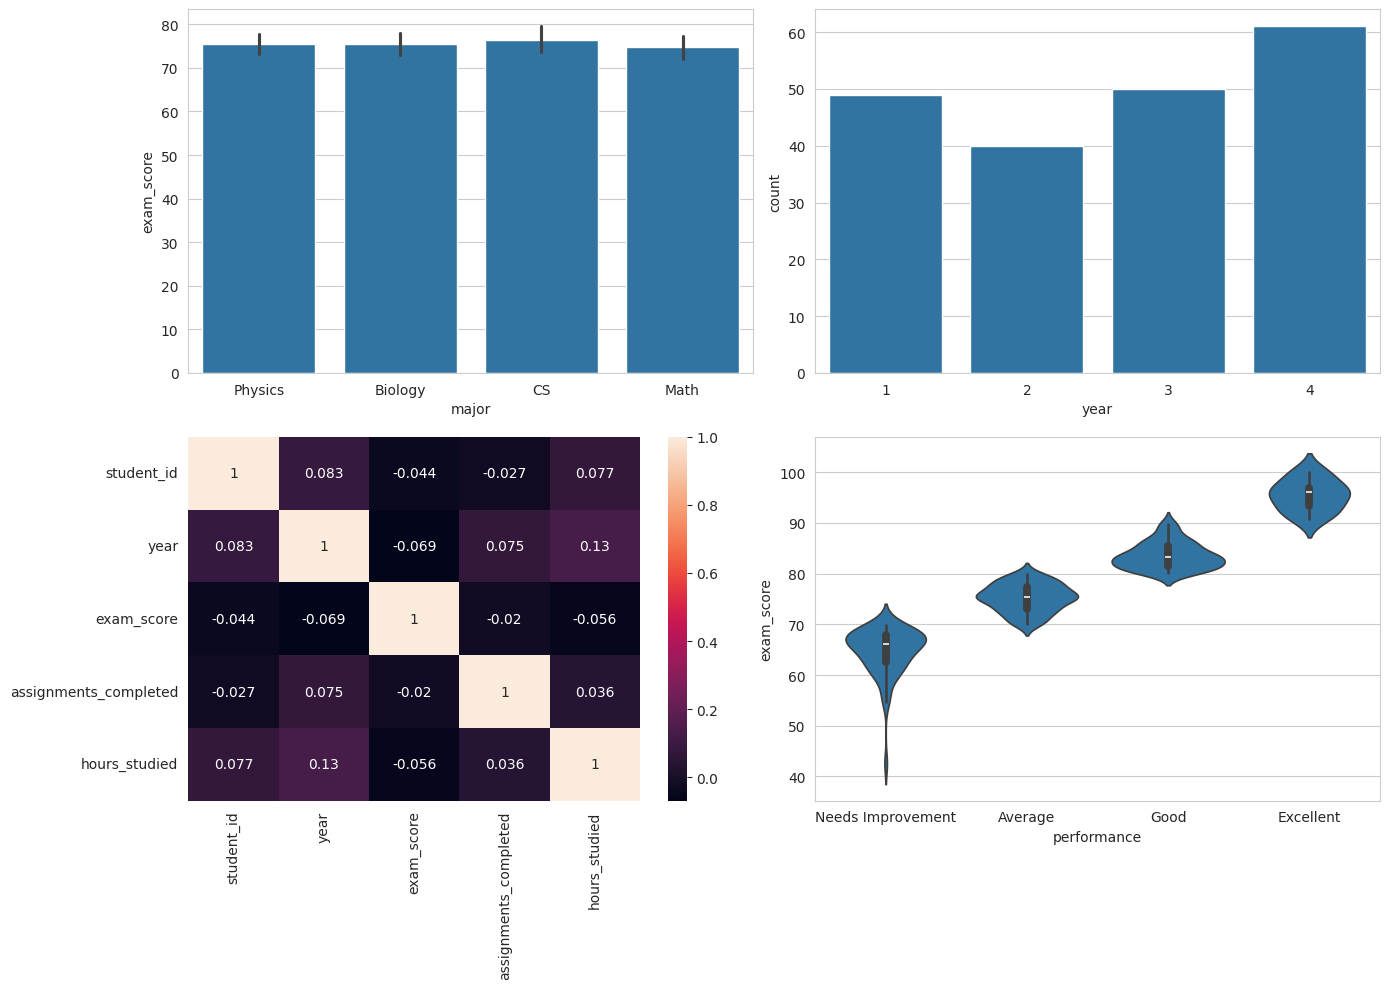

In [20]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

sns.barplot(data=df, x='major', y='exam_score', ax=ax[0,0])
sns.countplot(data=df, x='year', ax=ax[0,1])

sns.heatmap(df.select_dtypes(include=np.number).corr(), ax=ax[1,0], annot=True)

sns.violinplot(data=df, x='performance', y='exam_score', ax=ax[1,1])

plt.tight_layout()
plt.show()

Exercise 7: Integration

In [21]:
np.random.seed(42)

n_customers = 500

customers = pd.DataFrame({
    'age': np.random.randint(18,70,n_customers),
    'income': np.random.normal(50000,20000,n_customers).clip(15000,150000),
    'purchase_frequency': np.random.poisson(5,n_customers),
    'avg_purchase_value': np.random.normal(100,30,n_customers).clip(10,500)
})

In [22]:
#Frequency calculations
max_freq = customers['purchase_frequency'].max()

customers['churn_risk'] = 1 - (customers['purchase_frequency']/max_freq)

customers['CLV'] = (
    customers['purchase_frequency']
    * customers['avg_purchase_value']
    * (1 + customers['churn_risk'])
)

In [23]:
#Age groups
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18,25,35,50,70],
    labels=['18-25','26-35','36-50','51-70']
)

In [25]:
#Groupings
#NB: Some weird future warning came. Deal with that before you submit
customers.groupby('age_group').agg({
    'income':'mean',
    'CLV':['mean','sum']
})

/tmp/ipykernel_13175/683691941.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customers.groupby('age_group').agg({


income         CLV               
                   mean        mean            sum
age_group                                         
18-25      51805.879852  704.492597   48609.989225
26-35      48747.148046  747.738562   54584.915035
36-50      48516.895668  732.796612  117247.457917
51-70      50713.163384  762.693498  141860.990683

In [26]:
customers.nlargest(50, 'CLV')

,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV,age_group
426,42,68713.567863,8,154.285448,0.333333,1645.711441,36-50
213,41,45580.608009,7,164.920221,0.416667,1635.458860,36-50
410,44,49344.934596,6,177.097211,0.500000,1593.874900,36-50
194,44,57331.964922,6,176.640590,0.500000,1589.765308,36-50
244,28,29255.076913,7,159.784979,0.416667,1584.534373,26-35
423,43,34443.666248,6,173.245130,0.500000,1559.206172,36-50
386,63,24200.782005,9,136.030443,0.250000,1530.342482,51-70
187,47,48889.046022,8,143.183371,0.333333,1527.289296,36-50
361,38,27490.219054,7,153.105028,0.416667,1518.291532,36-50
180,62,44611.863311,7,151.961479,0.416667,1506.951331,51-70


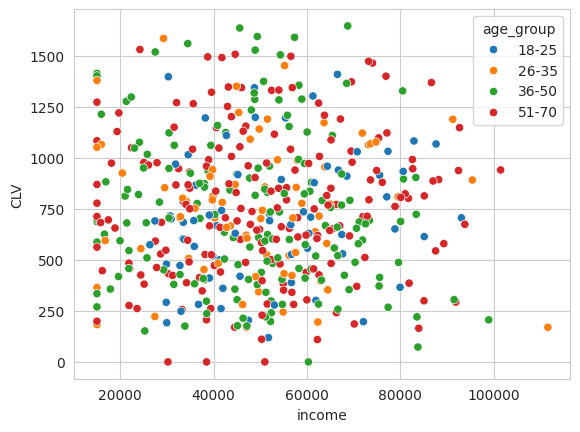

In [27]:
#scatter scatter plot
sns.scatterplot(data=customers, x='income', y='CLV', hue='age_group')
plt.show()

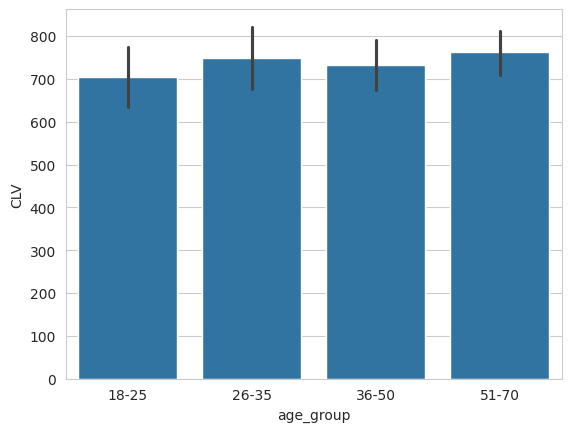

In [28]:
sns.barplot(data=customers, x='age_group', y='CLV')
plt.show()

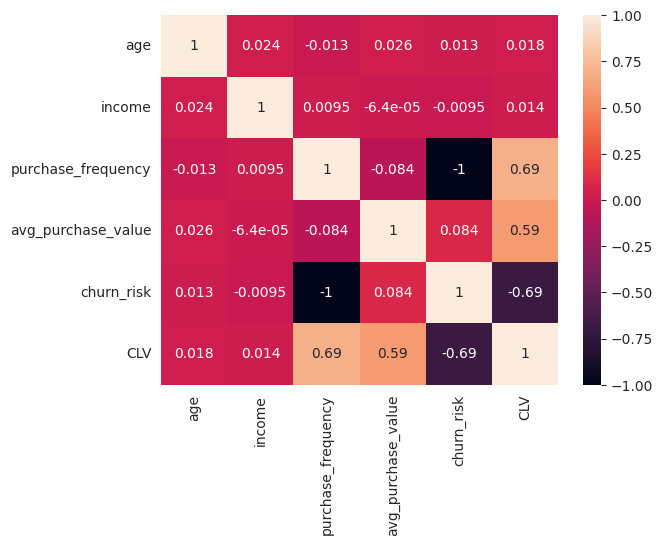

In [30]:
#Heatmaps
sns.heatmap(customers.select_dtypes(include=np.number).corr(), annot=True)
plt.show()